### News categorization using tf-idf and naive bayes


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/bbc_news_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.0+ KB


In [4]:
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [5]:
X = df['Text']
y = df['Category']

In [6]:
category_names = y.unique()
category_names

array(['business', 'tech', 'politics', 'sport', 'entertainment'],
      dtype=object)

In [7]:
value_counts = df['Category'].value_counts()
value_counts

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

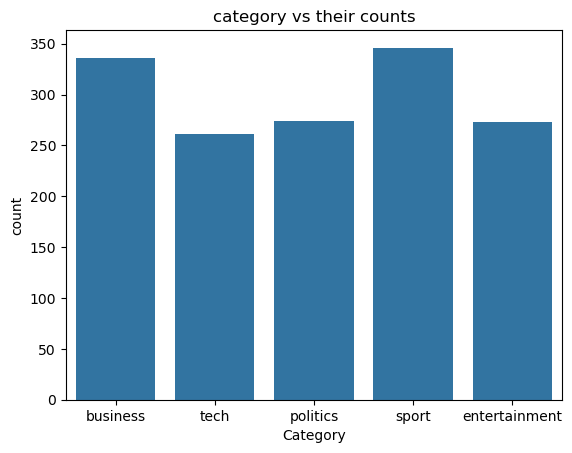

In [8]:
sns.countplot(x='Category',data=df)
plt.title("category vs their counts")
plt.show()

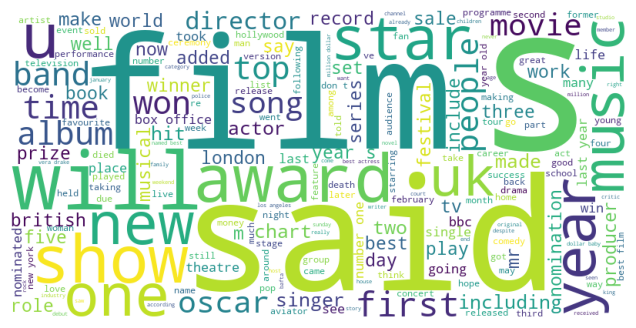

In [14]:
# generating word clouds 

from wordcloud import WordCloud

for category in category_names:
    text = " ".join(df[df['Category'] ==  category]['Text'].values)
    wc = WordCloud(width=800,height=400,background_color='white').generate(text)
plt.figure(figsize=(8,4))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
X_train

1166    fuming robinson blasts officials england coach...
1106    huge rush for jet airways shares indian airlin...
538     voters  don t trust politicians  eight out of ...
439     dundee utd 4-1 aberdeen dundee united eased in...
1478    visa row mandarin made sir john the top civil ...
                              ...                        
1130    blair  said he would stand down  tony blair pr...
1294    us trade gap hits record in 2004 the gap betwe...
860     tories pledge free sports lessons children wou...
1459    dance music not dead says fatboy dj norman coo...
1126    greek pair attend drugs hearing greek sprinter...
Name: Text, Length: 1192, dtype: object

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [19]:
# classificaiton report 

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



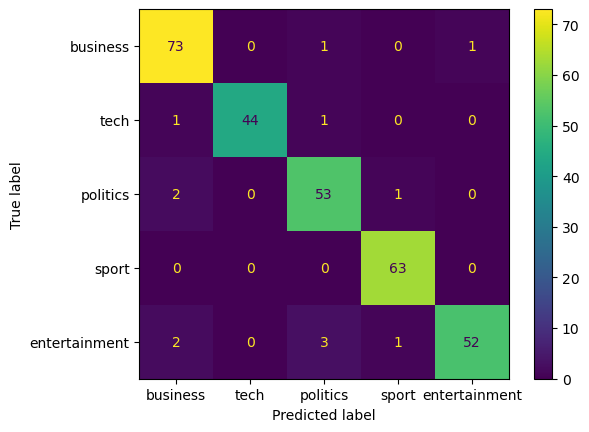

In [23]:
# conufsion matrix 

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=category_names).plot()

In [25]:
# train with new articles 

texts = ['Whats happenign there soomeone died']
prediction = model.predict(texts)
print(prediction)

['entertainment']


In [26]:
# save model 

import joblib

joblib.dump(model,'model.joblib')
print('Success')

Success
